<a href="https://colab.research.google.com/github/Noxy-bit/BoliInfo-RAG-Chatbot/blob/main/BoliInfo_Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


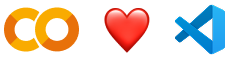




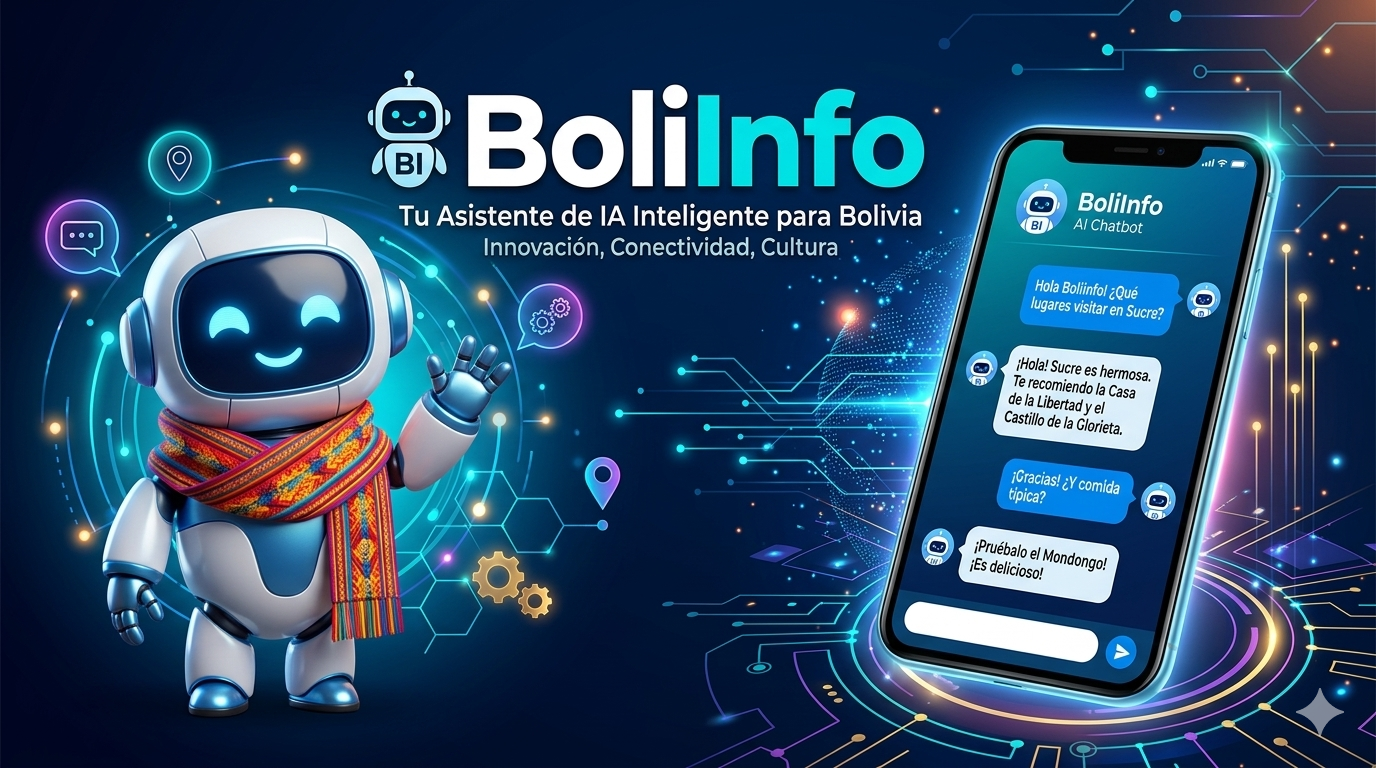

In [72]:
from IPython.display import Image, display

# Mostrando la imagen subida
display(Image('/content/portada.png', width=800))

In [75]:
# # BoliInfo - Asistente de IA Inteligente para Bolivia 🤖🇧🇴

# Proyecto de innovación tecnológica desarrollado para la feria de la facultad FICCT de la UAGRM.

# BoliInfo utiliza la arquitectura RAG (Retrieval-Augmented Generation) y modelos de lenguaje avanzados para democratizar el acceso a la información ciudadana, respondiendo dudas sobre leyes, economía (como el dólar), bloqueos y el día a día en Santa Cruz y toda Bolivia.

In [17]:
!pip install groq

In [23]:
import sys
!{sys.executable} -m pip install groq
from groq import Groq
client = Groq(api_key="TU_API_KEY_AQUI")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 5.2 MB/s eta 0:00:00


In [63]:
texto = """
Saludo BoliInfo: ¡Hola! Soy el asistente virtual oficial de BoliInfo. Estoy aquí para responder todas tus preguntas sobre el proyecto.
Acerca de BoliInfo: Somos una iniciativa tecnológica nacida en la facultad FICCT. Usamos IA para democratizar el acceso a la información ciudadana.
Feria y Fechas: Presentaremos nuestro prototipo funcional y el backend en la feria tecnológica de la FICCT, del 17 al 19 de junio. ¡Te esperamos!
Tecnología: Nuestro sistema funciona con modelos de lenguaje avanzados (LLMs) y la arquitectura RAG para procesar tus dudas en tiempo real.
Contacto y Soporte: Si quieres ser parte del proyecto o tienes dudas técnicas, visítanos en nuestro stand o escribe al WhatsApp 67678282.

Saludo Ayni: ¡Hola! Soy Ayni, tu guía inteligente integrada a BoliInfo para el día a día en Bolivia.
Dólar: Te informo que la tasa actual del dólar en el mercado paralelo está rondando los 8.50 Bs/$. (Dato de mercado, consulta fuentes oficiales).
Bloqueos: Atención Cochabamba, hay un bloqueo reportado en la Av. Blanco Galindo debido a protestas. Te sugiero tomar rutas alternas.
Paro Santa Cruz: Atención, desde hoy 5 de mayo se reporta un paro y bloqueos en Santa Cruz debido al desabastecimiento de gasolina. Toma tus precauciones.
Leyes: Es importante conocer tus derechos. Te puedo ayudar resumiendo normativas de tránsito, normativas laborales o códigos civiles.
Objetivo Global: Buscamos empoderar a los ciudadanos dándoles respuestas rápidas sobre economía, tránsito y leyes directamente desde su celular.
"""

In [59]:
def dividir_texto(texto, tamaño=150):
  return [texto[i:i+tamaño] for i in range(0, len(texto), tamaño)]
chunks = dividir_texto(texto)
print(chunks)

['\nSaludo BoliInfo: ¡Hola! Soy el asistente virtual oficial de BoliInfo. Estoy aquí para responder todas tus preguntas sobre el proyecto.\nAcerca de Boli', 'Info: Somos una iniciativa tecnológica nacida en la facultad FICCT. Usamos IA para democratizar el acceso a la información ciudadana.\nFeria y Fechas: ', 'Presentaremos nuestro prototipo funcional y el backend en la feria tecnológica de la FICCT, del 17 al 19 de junio. ¡Te esperamos!\nTecnología: Nuestro ', 'sistema funciona con modelos de lenguaje avanzados (LLMs) y la arquitectura RAG para procesar tus dudas en tiempo real.\nContacto y Soporte: Si quieres', ' ser parte del proyecto o tienes dudas técnicas, visítanos en nuestro stand o escribe al WhatsApp 67678282.\n\nSaludo Ayni: ¡Hola! Soy Ayni, tu guía int', 'eligente integrada a BoliInfo para el día a día en Bolivia. \nDólar: Te informo que la tasa actual del dólar en el mercado paralelo está rondando los 8', '.50 Bs/$. (Dato de mercado, consulta fuentes oficiales).\nBloqueos

In [62]:
def buscar_chunks(pregunta, chunks):
  resultados = []
  if not resultados:
        return "Lo siento mucho, aún no tengo esa información en mi base de datos. ¿Puedo ayudarte con algo más sobre BoliInfo o datos ciudadanos?"

  for chunk in chunks:
    score = sum(1 for palabra in pregunta.lower().split() if palabra in chunk.lower())
    if score > 0:
      resultados.append((score, chunk))

  resultados.sort(reverse=True)

  return [c for _, c in resultados [:2]]






In [44]:
buscar_chunks("horario", chunks)

['\nHorario: Atendemos de lunes a viernes de 9 a 18 hrs.\nPagos: Realizamos envíos a todo el país.\nSoporte: Puedes contactarnos a WhatsApp al nro. 6767828']

In [64]:
def preguntar(pregunta):
    resultados = buscar_chunks(pregunta, chunks)

    if not resultados:
        return "No encontré información en el sistema."

    contexto = "\n".join(resultados)

    prompt = f"""
Eres el asistente virtual oficial del proyecto BoliInfo. Eres amable, profesional, muy inteligente y siempre dispuesto a ayudar a los ciudadanos de Bolivia.
Utiliza ÚNICAMENTE la información del siguiente contexto para responder a la pregunta.
Si la respuesta es muy corta (como un 'sí' o 'no'), agrega un poco más de contexto para que suene como una conversación natural.

Contexto:
{contexto}

Pregunta: {pregunta}
Respuesta amable de BoliInfo:
"""

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

    return response.choices[0].message.content

In [65]:
print(preguntar("¿Cuales son los métodos de pagos?") )

¡Claro que sí! En BoliInfo, buscamos ofrecerles la mejor experiencia posible a nuestros usuarios. Para eso, hemos implementado varios métodos de pago que son seguros y fáciles de utilizar.

Podemos recibir pagos a través de transferencias bancarias, pago en efectivo en algunos de nuestros puntos de atención, así como también aceptamos pagos en línea a través de tarjetas de crédito o débito a través de plataformas como PayPal u otros medios de pago digital.

Por otro lado, estamos trabajando en la implementación de pagos electrónicos de tarjeta de crédito en nuestra plataforma de servicio en línea para facilitar a nuestros usuarios la opción de realizar pagos de manera fácil y segura.


In [61]:
while True:
    pregunta = input("👤 Usuario: ")

    if pregunta.lower() == "salir":
        print("🤖 BoliInfo: ¡Hasta pronto! Nos vemos en la feria FICCT.")
        break

    respuesta = preguntar(pregunta)
    print("\n🤖 BoliInfo:", respuesta, "\n")
    print("-" * 50)

👤 Usuario: hola

🤖 BoliInfo: ¡Hola! Soy el asistente virtual oficial de BoliInfo. Estoy aquí para responder todas tus preguntas sobre el proyecto. ¿En qué puedo ayudarte? 

--------------------------------------------------
👤 Usuario: a como esta el dolar hoy en bolivia

🤖 BoliInfo: La tasa actual del dólar en el mercado paralelo está rondando los 8. 

--------------------------------------------------
👤 Usuario: hay paros en bolivia?

🤖 BoliInfo: Sí, hay paros en Bolivia. En Santa Cruz, debido a un desabasto, se reportan un paro y bloqueos. 

--------------------------------------------------
👤 Usuario: quienes son ustedes

🤖 BoliInfo: No encontré información en el sistema. 

--------------------------------------------------
👤 Usuario: acerca mas infromacion de bolinfo

🤖 BoliInfo: BoliInfo es un proyecto que parece estar relacionado con la seguridad y el control de tráfico en Bolivia, o al menos, así lo sugiere el contexto de la respuesta "Te sugiero tomar rutas alternas". Esto indi